In [1]:
import os
import numpy as np
from numpy import random as rng
import healpy as hp

import matplotlib.pyplot as plt
import matplotlib.path as mpath
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from cmcrameri import cm 
from matplotlib.patches import Ellipse
from PIL import Image

from scipy.odr import ODR, Model, Data
from scipy import constants
from scipy.stats import spearmanr
from scipy.ndimage import gaussian_filter
from scipy import linalg as lng

from astropy.io import fits
from astropy.wcs import WCS
from astropy.convolution import Gaussian2DKernel, convolve

from reproject import reproject_interp
from reproject.mosaicking import find_optimal_celestial_wcs, reproject_and_coadd

In [2]:
LINUX_DIRECTORY = "/scratch/nas_comap1/jgalla/MPHYS_PROJECT"

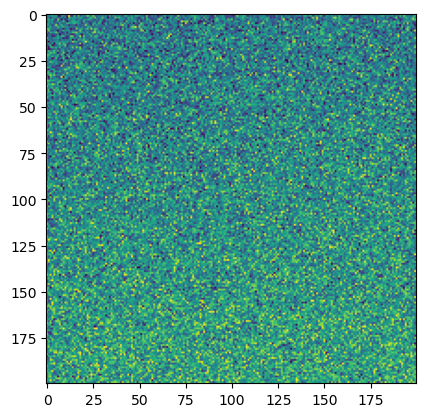

Noise covarience matrix shape: (40000, 40000)
Inv Noise covarience matrix shape: (40000, 40000)
Template matrix shape: (40000, 3)
Transposed Template matrix shape: (3, 40000)
Covarience matrix shape: (3, 3)
[ 0.22540754  2.69401549 -0.45092618]
[[ 4411.16666667  3300.08333333  6633.33333333]
 [ 3300.08333333  4411.16666667  6633.33333333]
 [ 6633.33333333  6633.33333333 13333.33333333]]


In [3]:
def unpack2D(arr):
    unpacked = []
    for row in arr:
        unpacked = np.append(unpacked, row)
    return unpacked


def fit_templates(data_vec, noise_vec, template_matrix):
    noise_cov_matrix = np.diag(noise_vec)
    inv_noise_cov_matrix = lng.inv(noise_cov_matrix)
    print(f"Noise covarience matrix shape: {noise_cov_matrix.shape}")
    print(f"Inv Noise covarience matrix shape: {inv_noise_cov_matrix.shape}")
    print(f"Template matrix shape: {template_matrix.shape}")
    print(f"Transposed Template matrix shape: {template_matrix.T.shape}")
    cov_matrix = template_matrix.T @ inv_noise_cov_matrix @ template_matrix
    print(f"Covarience matrix shape: {cov_matrix.shape}")
    fitted_coefficients = lng.inv(cov_matrix) @ template_matrix.T @ inv_noise_cov_matrix @ data_vec
    return fitted_coefficients, cov_matrix


def flat_baseline_template(shape):
    return np.full(shape, 1)


def linear_baseline_templates(shape):
    norm_flat = np.full(shape, 1)

    x_map = np.empty(shape)
    for i, col in enumerate(norm_flat):
        x_map[:, i] = i/shape[1] * col
    
    y_map = np.empty(shape)
    for i, row in enumerate(np.rot90(norm_flat,3)):
        y_map[i, :] = i/shape[0] * row
    # print(y_map)
    return x_map, y_map

noise_level = 3

test_template = 0.2*linear_baseline_templates((200, 200))[0] + 2.8*linear_baseline_templates((200, 200))[1] - 0.5*flat_baseline_template((200, 200))

noisey_testtemplate = test_template + rng.normal(0, noise_level, size = (200, 200))

plt.imshow(noisey_testtemplate, vmin=np.nanpercentile(noisey_testtemplate, 0.5), vmax=np.nanpercentile(noisey_testtemplate, 99.5))
plt.show()

dvec = unpack2D(noisey_testtemplate)
tmat = np.array([
    unpack2D(linear_baseline_templates(noisey_testtemplate.shape)[0]),
    unpack2D(linear_baseline_templates(noisey_testtemplate.shape)[1]),
    unpack2D(flat_baseline_template(noisey_testtemplate.shape))
]).transpose()
nvec = unpack2D(np.full_like(noisey_testtemplate, noise_level))

coefs, cov = fit_templates(dvec, nvec, tmat)

print(coefs)
print(cov)